# Power Price Forecast Methodology

Four target variables are forecasted for France:
- electricity load
- solar production
- wind production
- electricity price

Electricity load, solar production, and wind production are first modeled separately, as they are primarily driven by different underlying factors. Electricity price is then modeled using the forecasted values of the previous three series, since power prices depend strongly on the balance between electricity supply and demand.

The validation framework uses:
- 2020–2023 for training
- 2024 for validation

This setup provides an out-of-sample estimate of forecasting performance before generating the final 2025 forecasts.

The analysis begins by importing the training target dataset and visualizing the electricity load time series over the 2020–2024 period in order to better understand its temporal patterns, seasonality, and overall behavior.

<Axes: xlabel='start_date'>

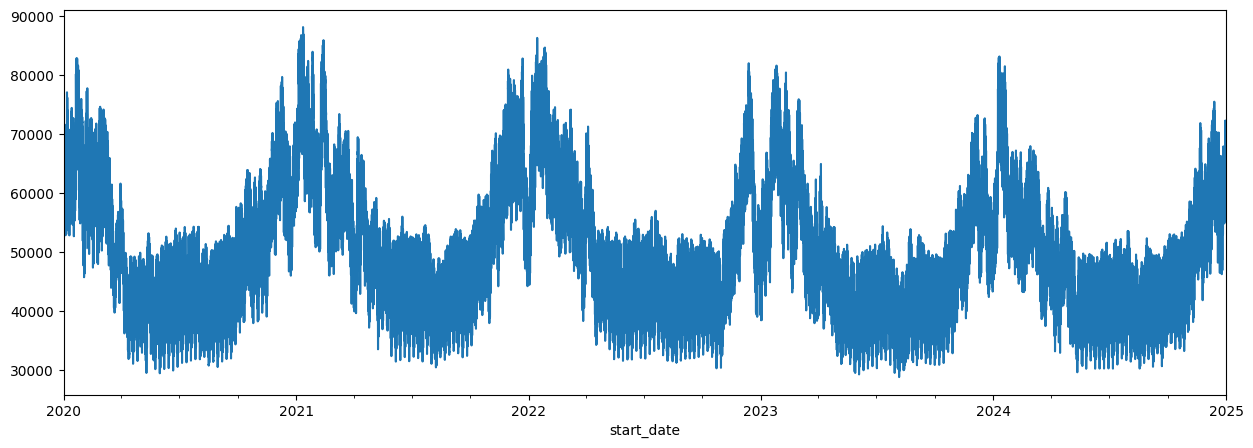

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.functions import load_train_data

target_train, weather_train, network_train = load_train_data()

target_train["FR_load_actual"].plot(figsize=(15, 5))

# Power Demand Modelling

The total load time series shows clear annual seasonality, with higher electricity consumption during the winter months and lower consumption during the summer months. This is expected for France, where electric heating represents a significant share of total electricity demand.

When zooming in further, weekly and daily seasonal patterns are also visible. Demand tends to be higher on weekdays and during late morning, afternoon, and evening hours, reflecting typical residential and commercial consumption patterns.

No strong long-term trend is observed over the 2020–2024 period, as the overall amplitude and average consumption levels remain relatively stable throughout the time horizon.

As a result of these seasonalities, total load is expected to be primarily influenced by calendar-related features such as:
- day of year
- day of week
- hour of day

To capture the cyclical nature of these variables, sine and cosine transformations are applied to the corresponding calendar features.

Electricity load is also expected to be influenced by temperature. The dataset provides temperature values for multiple geographical tiles across France, without additional information regarding population, industrial activity, or other regional characteristics.

As an experiment, temperatures from individual tiles were initially used as separate input features in order to derive feature importances and potentially capture regional effects. However, model performance deteriorated, likely due to the high dimensionality and noise introduced by the large number of correlated temperature variables.

Better results were obtained by using the average temperature across all tiles as a single aggregated feature.

Further analysis could potentially improve the model by:
- investigating correlations between load and individual geographical tiles
- using an optimization algorithm for tile selection
- introducing weighted regional aggregation schemes

However, for the purpose of this exercise, average temperature appears to provide a sufficiently robust feature.

There are a total of 64 missing target values, mostly concentrated within a few days during the 2020–2024 period. These rows are excluded from the training and validation sets.

From visual inspection, the load time series does not appear to contain major outliers or spurious values.

First, calendar and temperature-related features are derived.

In [2]:
from src.functions import (
    add_calendar_features, 
    add_avg_weather_features, 
)

# Adding calendar features
target_train = add_calendar_features(target_train)

# Adding mean weather features among all available tiles
target_train = add_avg_weather_features(target_train, weather_train)

By generating a scatter plot between average temperature and total electricity load, the expected relationship can be observed.

Electricity load is highest during the coldest winter temperatures and generally decreases as temperature increases, reaching its minimum at approximately 10–20°C.

For very high summer temperatures, load begins increasing again, likely due to cooling demand. However, peak summer loads remain significantly lower than peak winter loads, indicating that heating demand has a substantially stronger effect on total electricity consumption in France than cooling demand.

<Axes: xlabel='temp_avg', ylabel='FR_load_actual'>

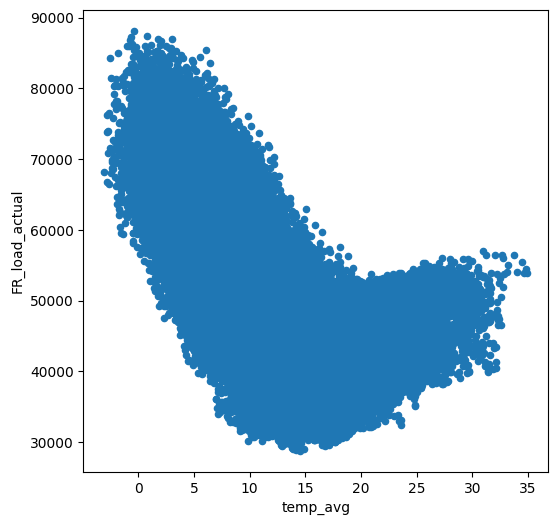

In [3]:
target_train.plot.scatter(
    x="temp_avg",
    y="FR_load_actual",
    figsize=(6, 6),
)

A model is then fitted to estimate total electricity load using the engineered calendar and temperature features.

Several model types were tested during experimentation. Random Forest was ultimately selected, as it achieved relatively good MAE and RMSE performance on the validation period (calendar year 2024), while also producing realistic and stable time series predictions.

A comparison between the actual and predicted load series over the validation period is shown below.

FR_load_actual
MAE:  2,134.64
RMSE: 2,842.66



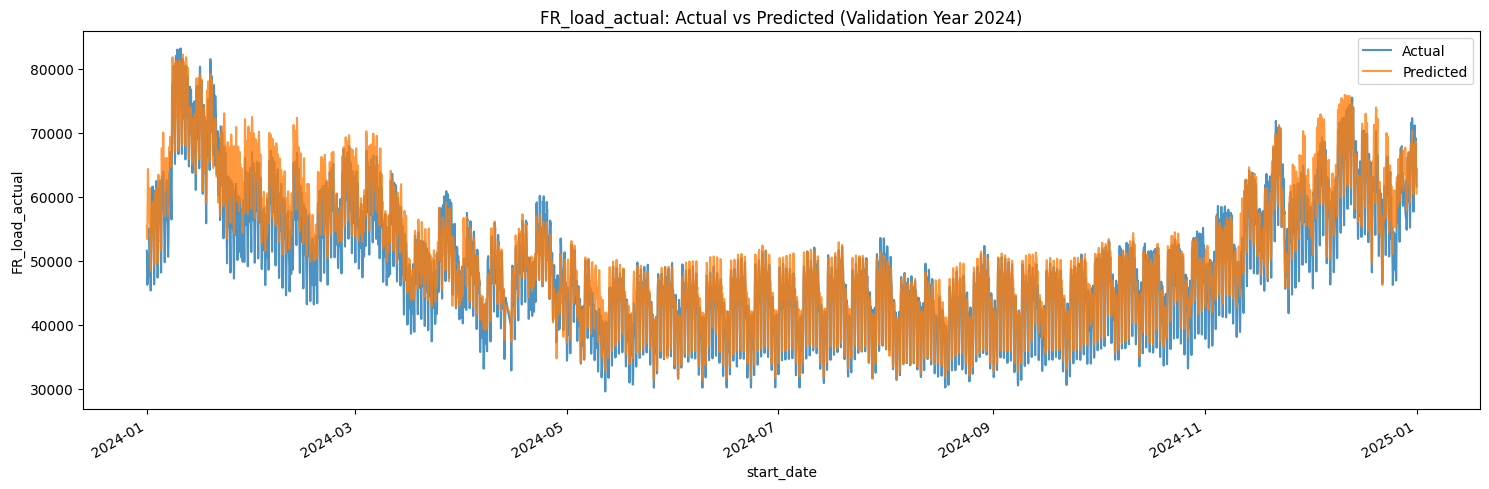

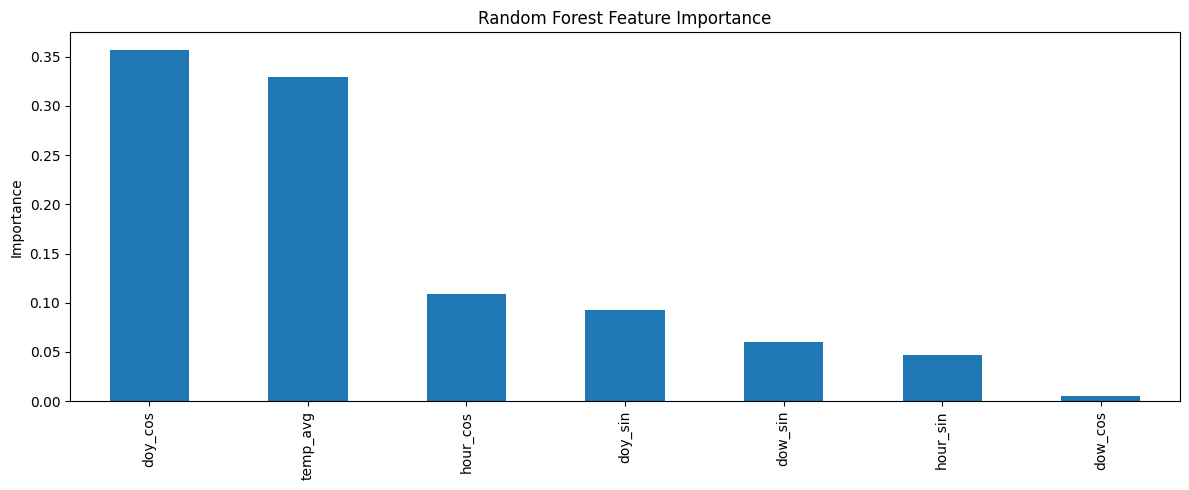

In [4]:
from src.functions import train_single_model, TARGET_CONFIG

load_dict = TARGET_CONFIG["load"]
TARGET = load_dict["target"]

model_load, metrics, valid_load = train_single_model(
    target_train,
    TARGET,
    load_dict["features"],
    model_type=load_dict["model_type"],
    return_train=False,
)

valid_load[[TARGET, "pred"]].plot(
    figsize=(15, 5),
    alpha=0.8,
)

plt.title(f"{TARGET}: Actual vs Predicted (Validation Year 2024)")
plt.ylabel(TARGET)
plt.legend(["Actual", "Predicted"])
plt.tight_layout()
plt.show()

if load_dict["model_type"] == "random_forest":
    # Feature importance
    feature_importance = (
        pd.Series(
            model_load.feature_importances_,
            index=load_dict["features"],
        )
        .sort_values(ascending=False)
    )

    feature_importance.plot.bar(
        figsize=(12, 5)
    )

    plt.title("Random Forest Feature Importance")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()


Annual seasonality is generally captured. Feature importances from RF model show that annual seasonality and average temperature are the most important features.

By also plotting for specific months below (January and July 2024), it can be observed that weekly and daily patterns are also captured. The model is better at predicting summer months than winter months (there is generally overprediction for several weeks during the winter period), which is expected as winter months display higher demands and more volatility/unpredictability depending on weather at specific tiles.

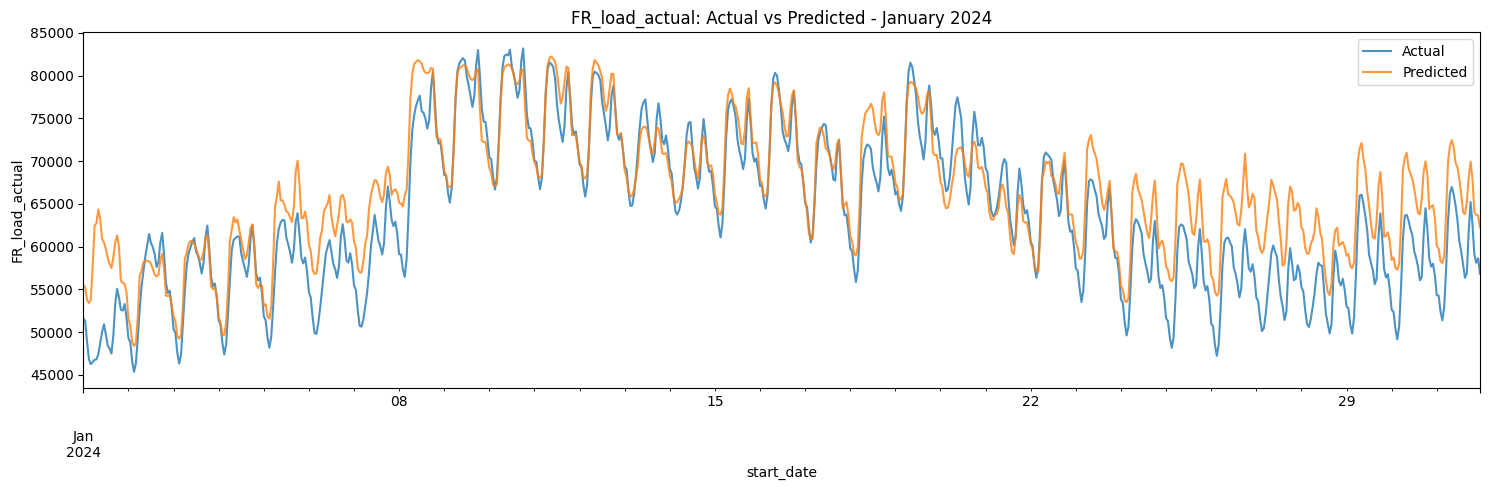

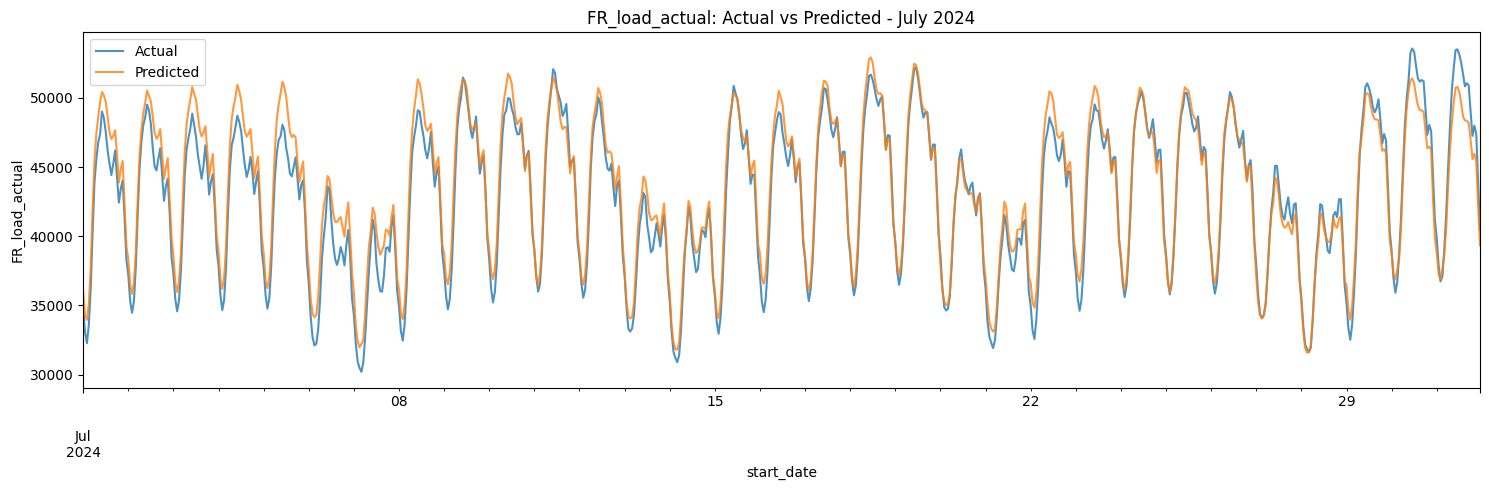

In [5]:
month_names = {
    "2024-01": "January 2024",
    "2024-07": "July 2024",
}

for month in ["2024-01", "2024-07"]:
    valid_load.loc[month, [TARGET, "pred"]].plot(
        figsize=(15, 5),
        alpha=0.8,
    )

    plt.title(
        f"{TARGET}: Actual vs Predicted - {month_names[month]}"
    )
    plt.ylabel(TARGET)
    plt.legend(["Actual", "Predicted"])
    plt.tight_layout()
    plt.show()

# Solar Output Modelling

Moving forward with modelling total solar output. Plotting the time series below. Some observations:
- There is some outlier value, which appears to be an error as it is much larger than neighboring values. Therefore it is replaced by an interpolated value.
- There are some missing values around September-October of 2024.
- Solar output exhibits annual seasonality which is expected as maximum output coincides with longer and sunnier days during the summer period.
- There is a discernible long-term upward trend. This should be due to the increasing solar production capacity.

<Axes: xlabel='start_date'>

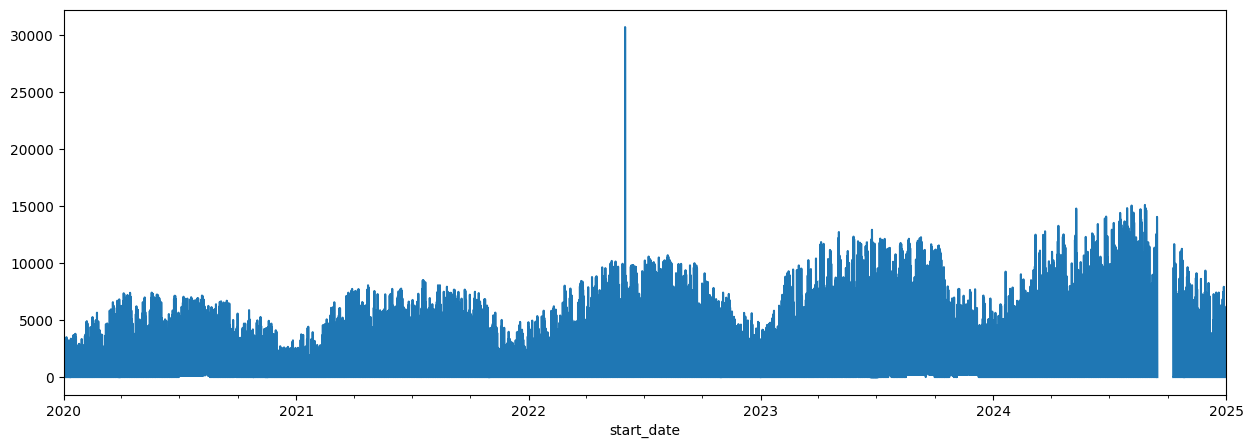

In [6]:
target_train["FR_solar_actual"].plot(figsize=(15, 5))

Total solar output should be influenced by solar capacity, surface solar radiation (ssrd) and cloud cover (tcc). Day of year (annual seasonality) is also considered as feature although it should act mostly as a proxy for solar radiation and cloud cover.

Below, the outlying values are first identified and replaced with interpolated values. Then, the features are derived and collected into the target dataframe and a model is fit.

FR_solar_actual
MAE:  782.33
RMSE: 1,407.49



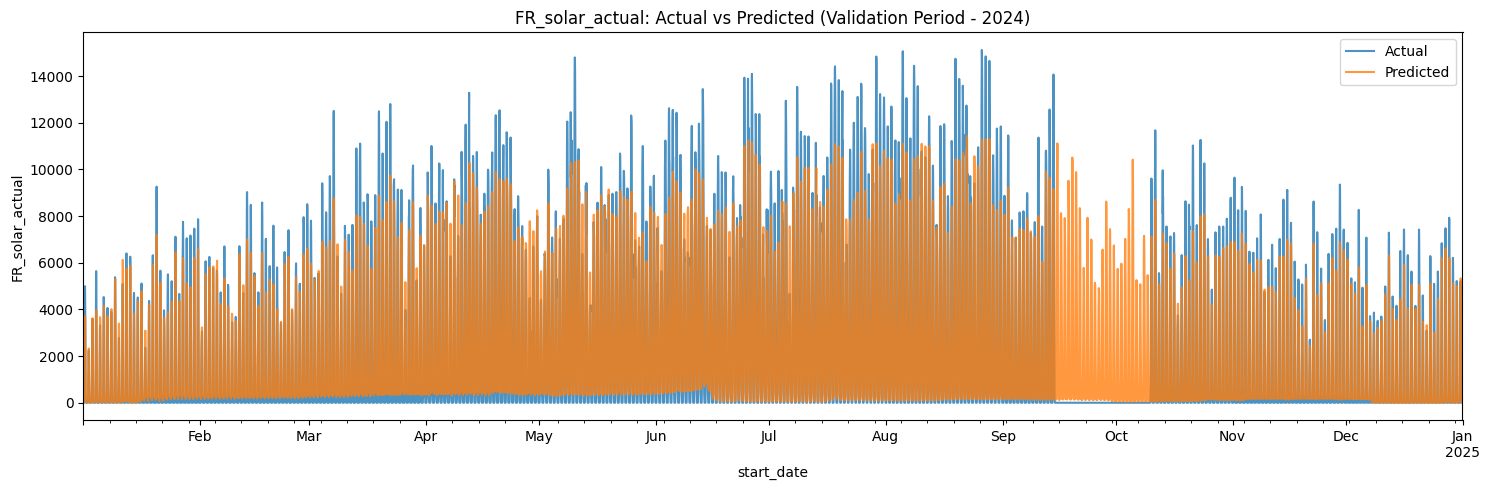

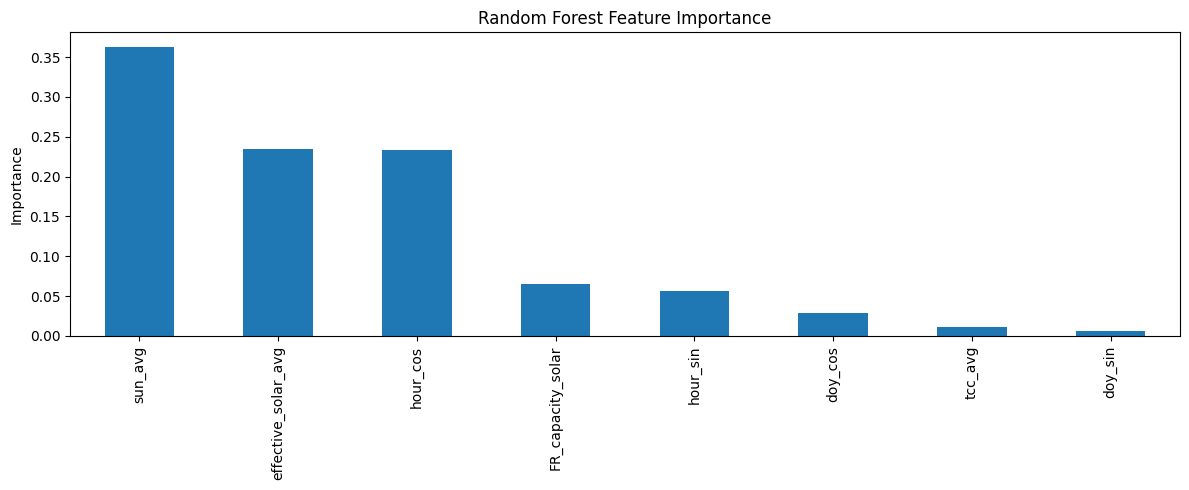

In [7]:
from src.functions import interpolate_spurious_values, add_network_features, replace_long_zero_runs

solar_dict = TARGET_CONFIG["solar"]
TARGET = solar_dict["target"]

target_train[TARGET] = replace_long_zero_runs(target_train[TARGET], threshold=300)
target_train[TARGET] = interpolate_spurious_values(target_train[TARGET])

target_train = add_network_features(target_train, network_train)

model_solar, metrics, valid_solar, train = train_single_model(
    target_train,
    TARGET,
    solar_dict["features"],
    model_type=solar_dict["model_type"],
    return_train=True,
)

valid_solar[[TARGET, "pred"]].plot(
    figsize=(15, 5),
    alpha=0.8,
)

plt.title(f"{TARGET}: Actual vs Predicted (Validation Period - 2024)")
plt.ylabel(TARGET)
plt.legend(["Actual", "Predicted"])
plt.tight_layout()
plt.show()

if solar_dict["model_type"] == "random_forest":
    # Feature importance
    feature_importance = (
        pd.Series(
            model_solar.feature_importances_,
            index=solar_dict["features"],
        )
        .sort_values(ascending=False)
    )

    feature_importance.plot.bar(
        figsize=(12, 5)
    )

    plt.title("Random Forest Feature Importance")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()


The model generally captures the annual seasonality and also captures the daily seasonality as can be observed by plotting for specific months (January and July 2024) below. It also captures the general day-to-day amplitude variation pattern, although it is not as good at accurately predicting the daily peaks. In most cases, the model underestimates the daily peak. This was somewhat expected for a target variable like this with a baseline value of zero during night hours and a daily peak that is sensitive to the amount of sunlight at different geographic tiles. A few alternative options were tried, namely:
- Correlations of individual tile sunlight values with target variable were derived and the 30 tiles with highest correlations were directly considered as features in the model. Model performance was not improved.
- A lower-bias xgboost model was tried in order to avoid the averaging of the random forest and try to better capture the daily peaks. Although xgboost better captured daily peaks, the overall average RMSE and MAE were increased. So I finally kept the random forest as a lower-variance baseline model.
- A transformation of the target variable was tried, namely logarithmic with an additive constant inside the logarithm to avoid zeros inside the logarithm. Again, the peaks were improved but the overall model performance deteriorated and the night-hour zero baselines were not captured as well.

I think there is probably some more room for experimentation (by e.g. using some optimization algorithm for including/excluding individual tiles). Nevertheless, I think the above model is a decent baseline for the purpose of this exercise.

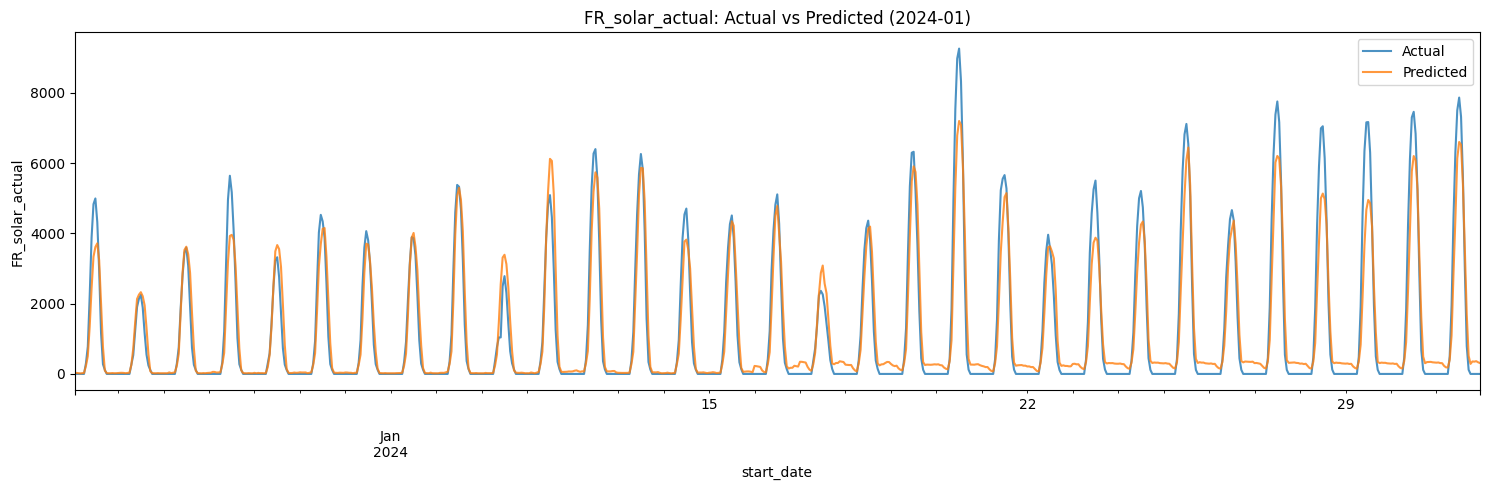

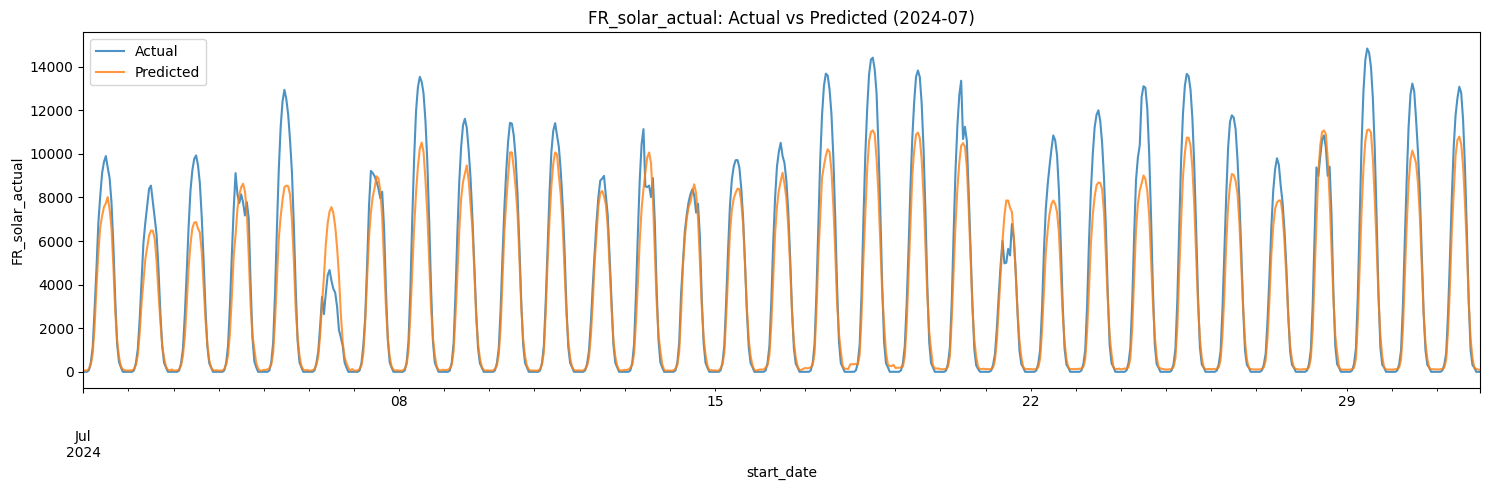

In [8]:
for month in ["2024-01", "2024-07"]:
    valid_solar.loc[month, [TARGET, "pred"]].plot(
        figsize=(15, 5),
        alpha=0.8,
    )

    plt.title(f"{TARGET}: Actual vs Predicted ({month})")
    plt.ylabel(TARGET)
    plt.legend(["Actual", "Predicted"])
    plt.tight_layout()
    plt.show()

# Wind Output Modelling

Moving forward with modelling total wind output which is plotted below. Some observations from the plotted time series:
- There are some outliers which are apparently wrong values and are replaced by interpolated values, as in solar case.
- There is some annual seasonality (although a bit blurry and not nearly as strong as in solar case) with higher output during winter.
- Daily patterns are not discernible, not even from single-month or single-day plots. Daily calendar features were tried in the model but did not appear to add any value.
- There is some mild long-term increasing trend which is likely associated with increased production capacity.

<Axes: xlabel='start_date'>

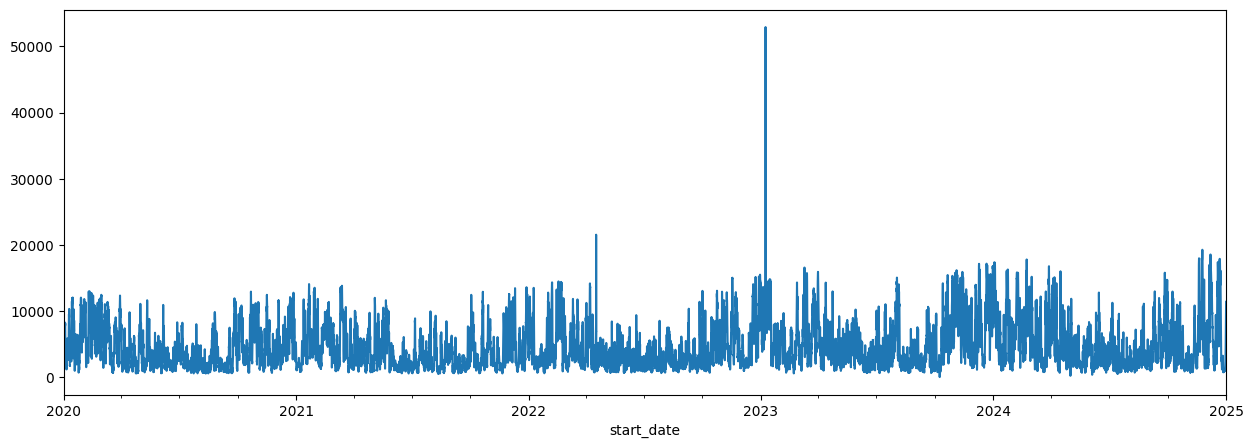

In [9]:
target_train["FR_wind_actual"].plot(figsize=(15, 5))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1019
[LightGBM] [Info] Number of data points in the train set: 35064, number of used features: 4
[LightGBM] [Info] Start training from score 4511.253037
FR_wind_actual
MAE:  965.66
RMSE: 1,330.48



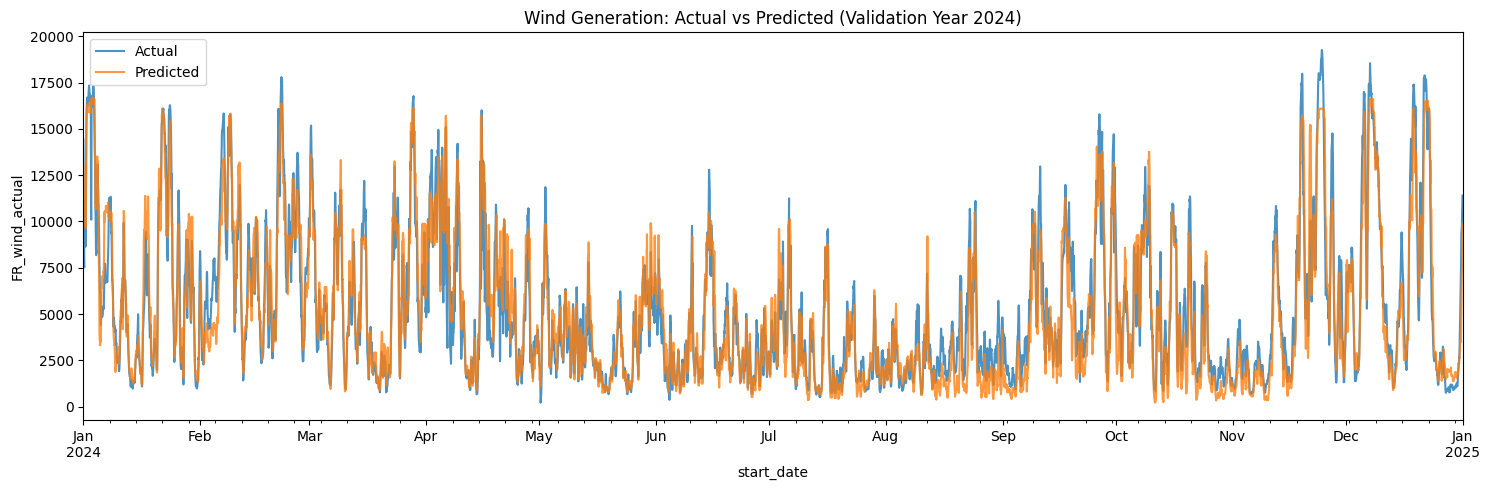

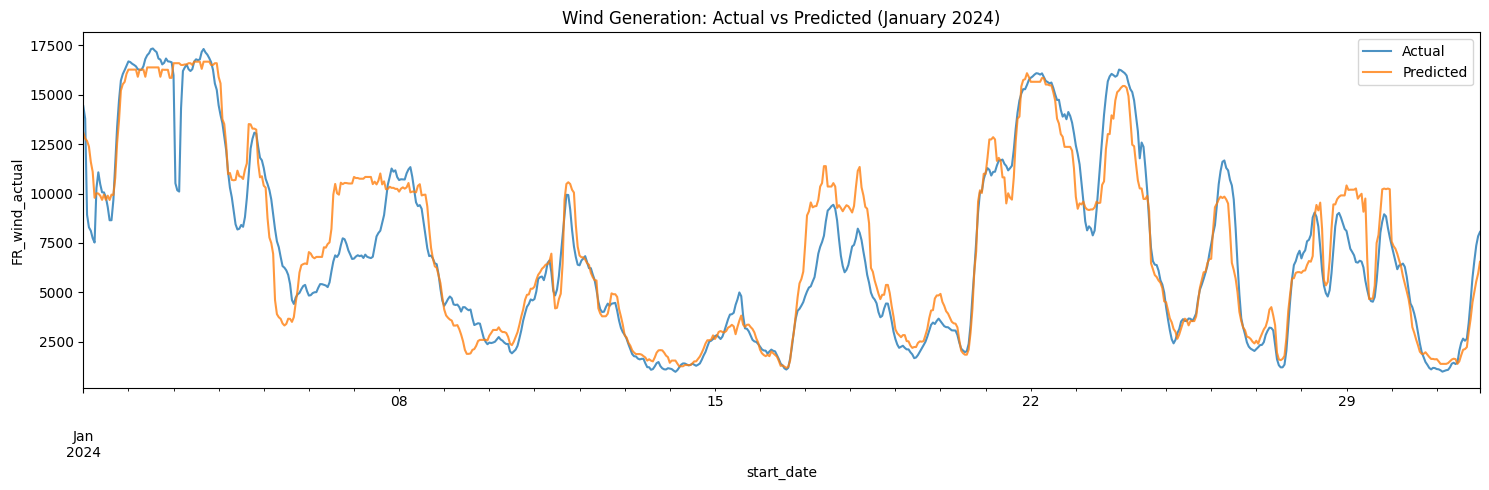

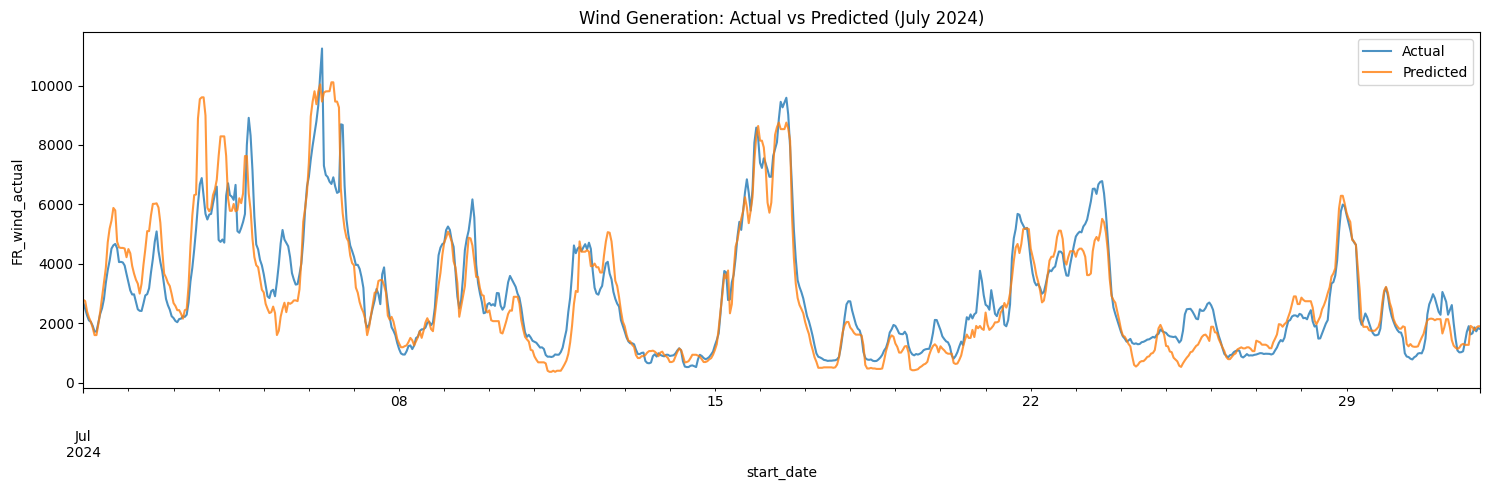

In [10]:
wind_dict = TARGET_CONFIG["wind"]
TARGET = wind_dict["target"]

target_train[TARGET] = interpolate_spurious_values(target_train[TARGET])

model_wind, metrics, valid_wind, train = train_single_model(
    target_train,
    TARGET,
    wind_dict["features"],
    model_type=wind_dict["model_type"],
    return_train=True,
)

valid_wind[[TARGET, "pred"]].plot(
    figsize=(15, 5),
    alpha=0.8,
)

plt.title("Wind Generation: Actual vs Predicted (Validation Year 2024)")
plt.ylabel(TARGET)
plt.legend(["Actual", "Predicted"])
plt.tight_layout()
plt.show()

month_names = {
    "2024-01": "January 2024",
    "2024-07": "July 2024",
}

for month in ["2024-01", "2024-07"]:
    valid_wind.loc[month, [TARGET, "pred"]].plot(
        figsize=(15, 5),
        alpha=0.8,
    )

    plt.title(
        f"Wind Generation: Actual vs Predicted ({month_names[month]})"
    )
    plt.ylabel(TARGET)
    plt.legend(["Actual", "Predicted"])
    plt.tight_layout()
    plt.show()



The LightGBM model is quite effective at predicting the time variation of the target variable. Although it appears to have some excess expressivity and jaggedness at times, the overall error metrics on the validation set are very good compared to other tried alternatives. A variation with higher regularization was tried but the results on the validation set were no better.

# Electricity Price Modelling

Finally moving to price target variable. Electricity price is influenced by both demand and supply, so previously modelled variables (namely electricity consumption, solar output and wind output) will be used as features for predicting price.

First, we plot the price time series:

<Axes: xlabel='start_date'>

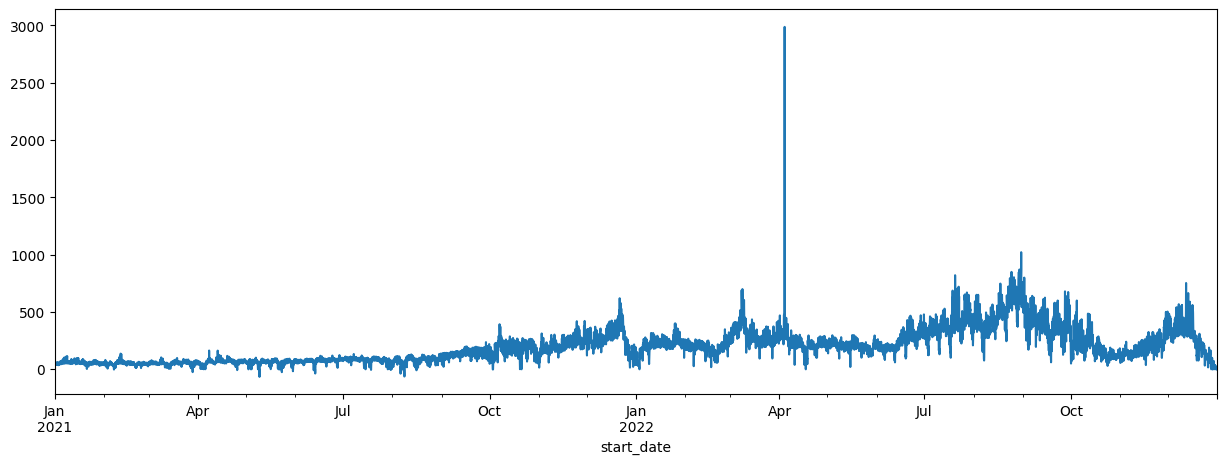

In [11]:
target_train.loc['2021':'2022', "FR_price_actual"].plot(figsize=(15, 5))

There are a couple of consecutive extreme value in April 2022, reaching about 3000€/MWh. By taking a closer look:

<Axes: xlabel='start_date'>

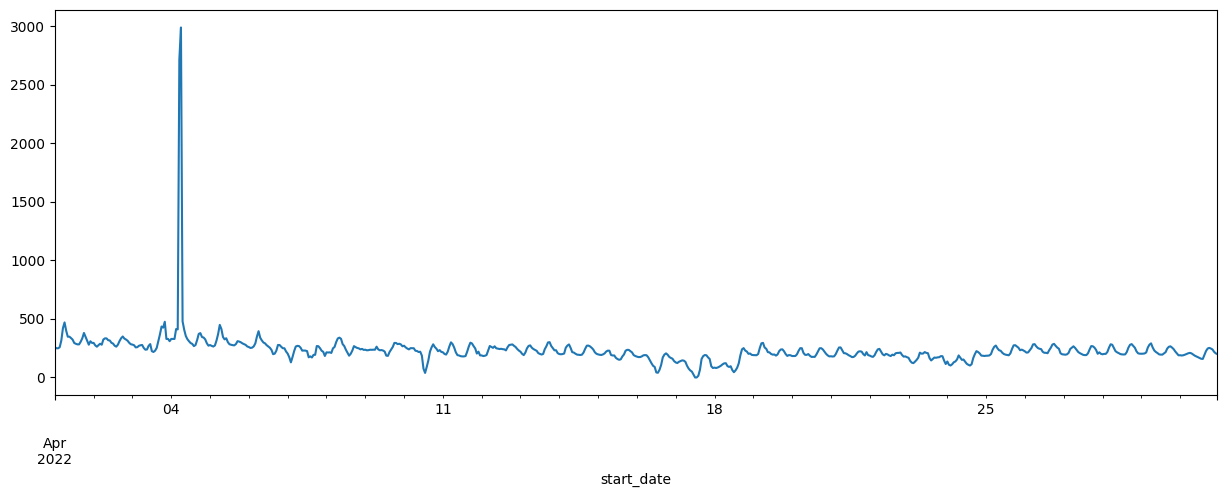

In [12]:
target_train.loc["2022-04", "FR_price_actual"].plot(figsize=(15, 5))

Although electricity prices can occasionally reach extreme values, the unusually large spikes observed in April 2022 appear substantially out of phase with the surrounding observations. Based on visual inspection, these values were capped at 500 €/MWh, which corresponds approximately to the highest non-anomalous values observed during the same period.

This correction relies on a dataset-specific, ad hoc rule and therefore reduces the generality and reusability of the pipeline. In future work, a more systematic outlier detection approach could be developed. For example, the current ratio-based method could be extended to incorporate absolute differences between neighbouring observations, which may help reduce false-positive detections in the price series when surrounding values are close to zero.

/var/folders/jl/f9h0g43s5js41bjx4wzw60br0000gn/T/ipykernel_33877/1586294623.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  & (target_train.index.to_period("M") == "2022-04"),


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3094
[LightGBM] [Info] Number of data points in the train set: 35035, number of used features: 13
[LightGBM] [Info] Start training from score 128.394831
FR_price_actual
MAE:  30.16
RMSE: 37.63



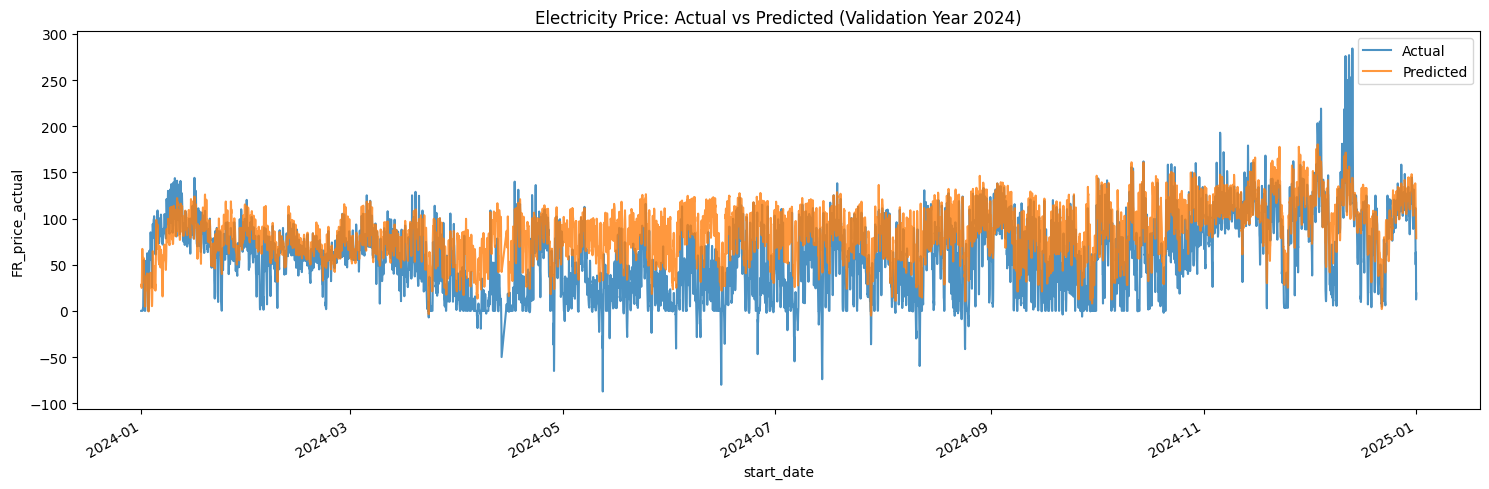

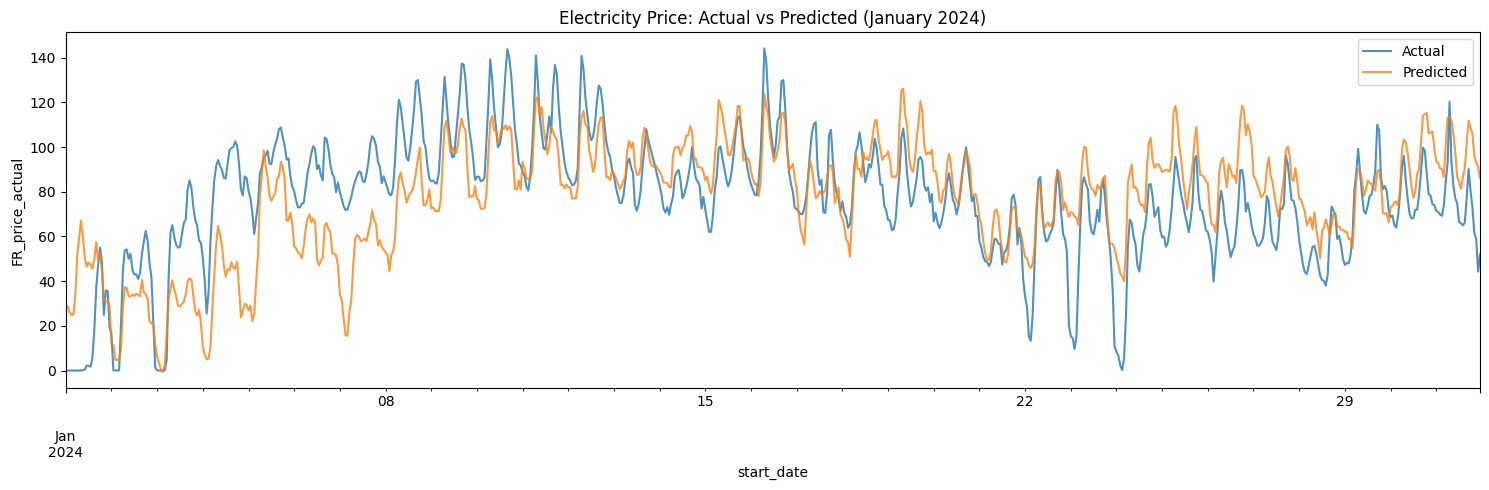

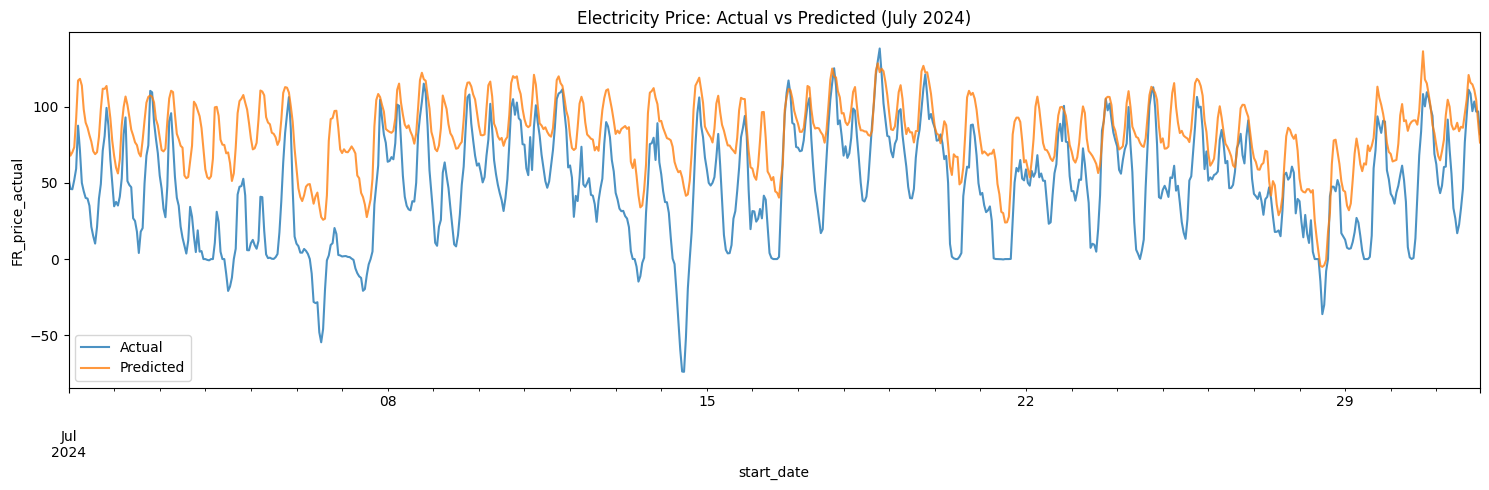

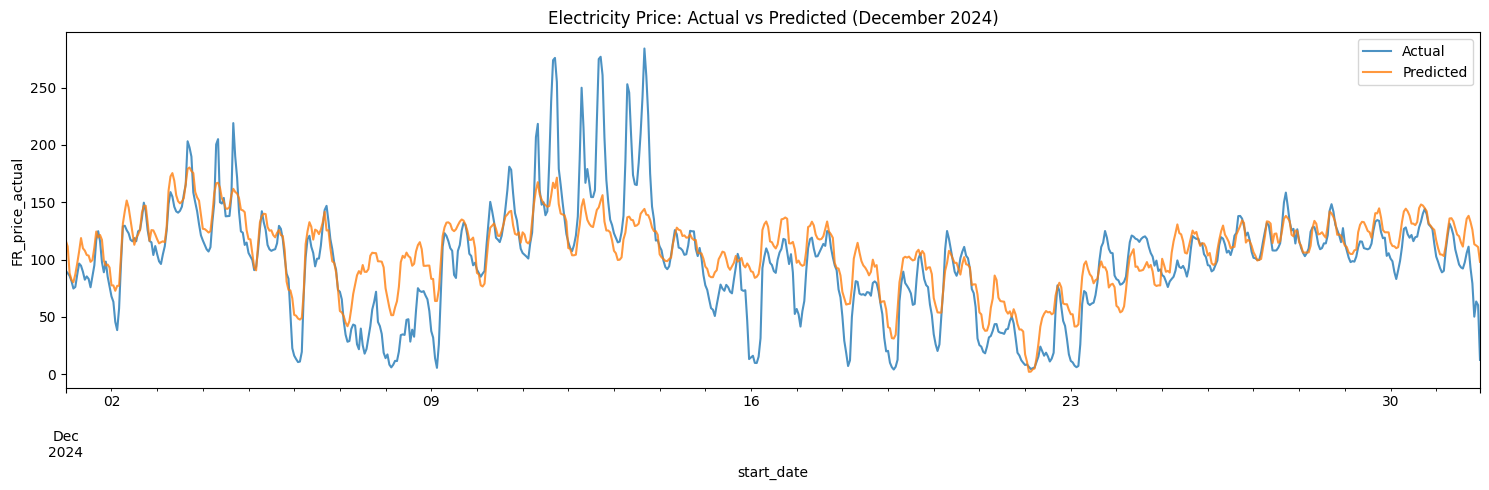

In [13]:
price_dict = TARGET_CONFIG["price"]
TARGET = price_dict["target"]

target_train.loc[
    target_train[TARGET].gt(500)
    & (target_train.index.to_period("M") == "2022-04"),
    TARGET,
] = 500

# For the price model, load/solar/wind are used as input features.
# In the training period, actual values are available.
# In the validation period, use the predictions already produced above.

train_mask = target_train.index < "2024-01-01"

target_train["FR_load_input"] = target_train["FR_load_actual"].astype("float64")
target_train["FR_solar_input"] = target_train["FR_solar_actual"].astype("float64")
target_train["FR_wind_input"] = target_train["FR_wind_actual"].astype("float64")

target_train.loc[valid_load.index, "FR_load_input"] = valid_load["pred"].astype("float64")
target_train.loc[valid_solar.index, "FR_solar_input"] = valid_solar["pred"].astype("float64")
target_train.loc[valid_wind.index, "FR_wind_input"] = valid_wind["pred"].astype("float64")

model_price, metrics_price, valid_price = train_single_model(
    target_train,
    TARGET,
    price_dict["features"],
    model_type=price_dict["model_type"],
    return_train=False,
)

valid_price[[TARGET, "pred"]].plot(
    figsize=(15, 5),
    alpha=0.8,
)

plt.title("Electricity Price: Actual vs Predicted (Validation Year 2024)")
plt.ylabel(TARGET)
plt.legend(["Actual", "Predicted"])
plt.tight_layout()
plt.show()

month_names = {
    "2024-01": "January 2024",
    "2024-07": "July 2024",
    "2024-12": "December 2024",
}

for month in ["2024-01", "2024-07", "2024-12"]:
    valid_price.loc[month, [TARGET, "pred"]].plot(
        figsize=(15, 5),
        alpha=0.8,
    )

    plt.title(
        f"Electricity Price: Actual vs Predicted ({month_names[month]})"
    )
    plt.ylabel(TARGET)
    plt.legend(["Actual", "Predicted"])
    plt.tight_layout()
    plt.show()



The price model appears to capture the overall temporal variation of the actual time series. Performance is generally stronger during the winter months than during the summer months. For example, during July 2024, the model systematically overestimates prices and fails to capture the extremes of low or negative prices observed in the actual series. More generally, summer 2024 prices appear lower and closer to zero than in previous years, a behaviour that is not fully reproduced by the model.

For December 2024, the model produces more accurate predictions, although some extreme price movements remain underrepresented. This was expected, as electricity prices are influenced by many factors and market dynamics, some of which are not explicitly represented in the provided dataset.

During validation, the price model used the predicted values of load, solar, and wind for 2024 rather than the actual values. This mirrors the final inference setup for 2025, where future values of these variables are unknown and must first be forecasted.

The final price model used to generate the submitted 2025 predictions is trained on all available historical data from 2020 to 2024.

# 2025 Forecast Sanity Check

The final predictions generated by `run.py` are loaded from the output parquet file. They are concatenated with the historical training targets to visually check that the 2025 forecasts are reasonable continuations of the 2020-2024 target data.

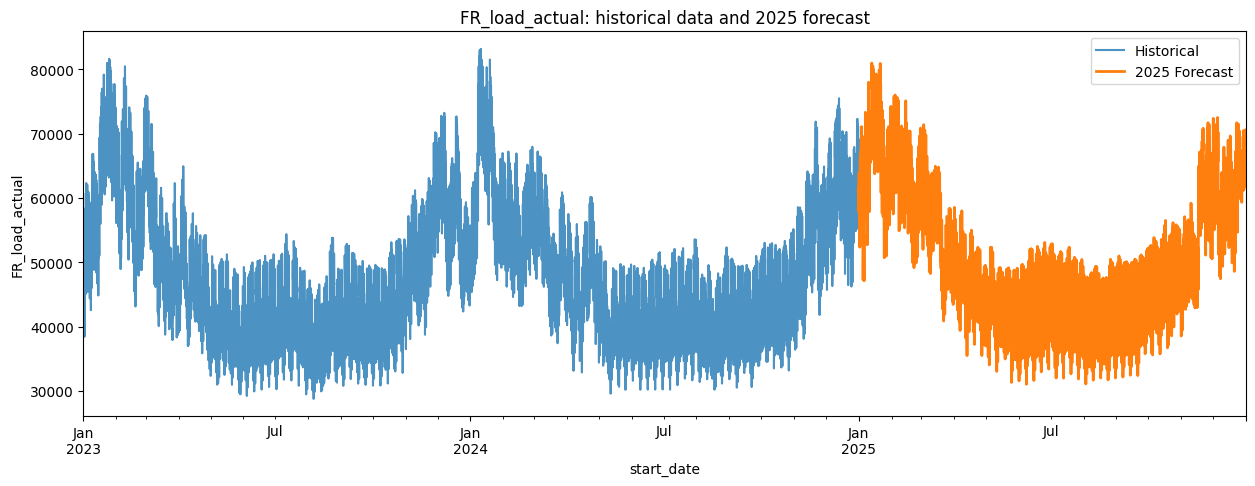

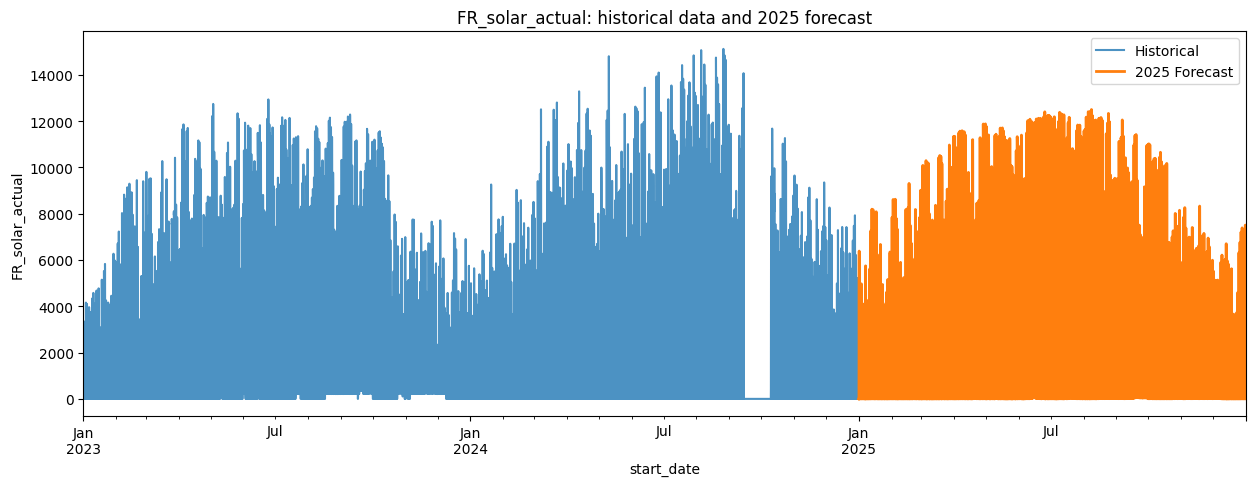

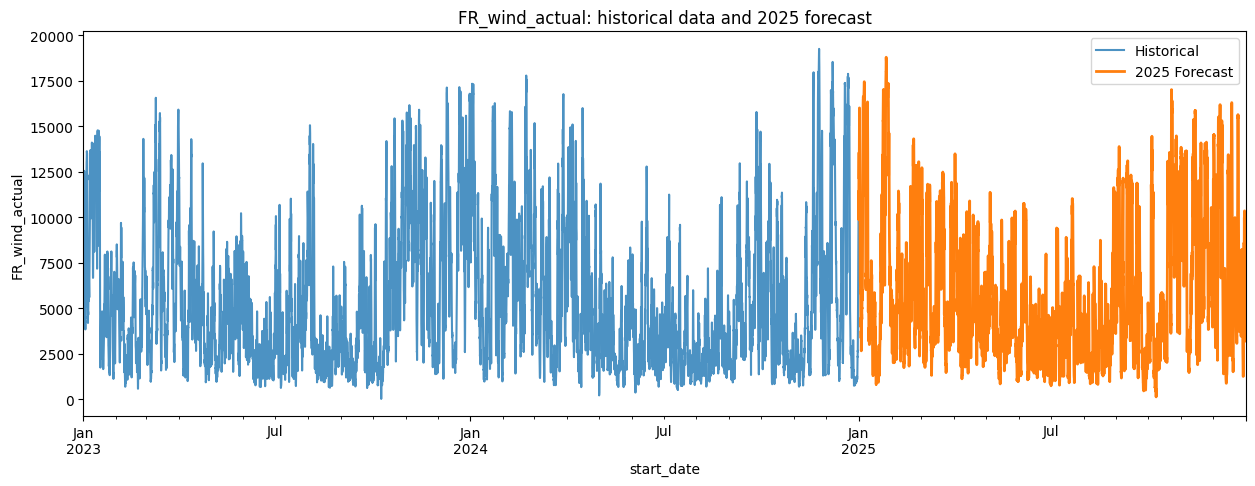

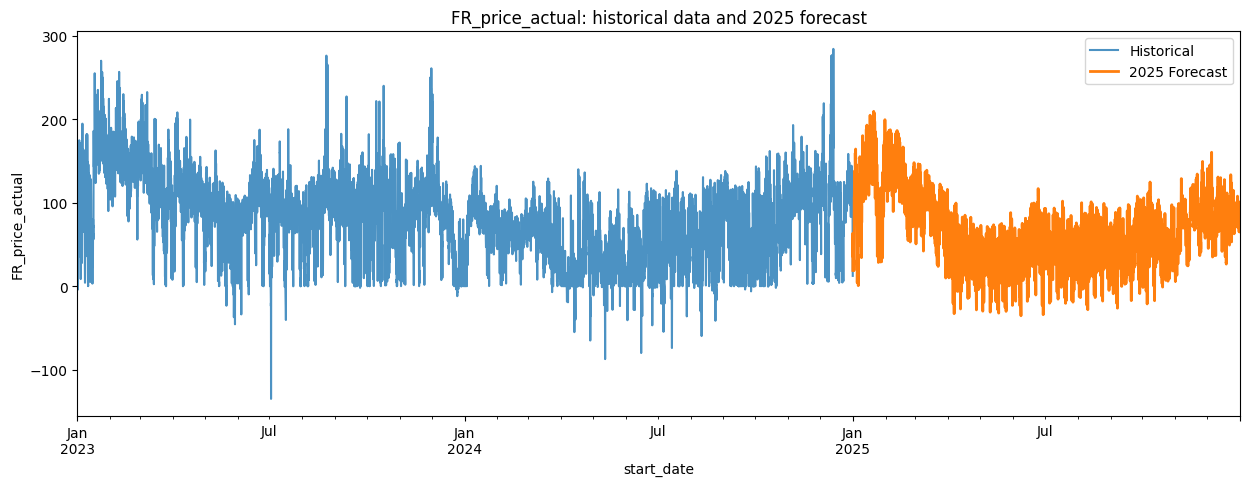

In [14]:
forecast_2025 = pd.read_parquet(PROJECT_ROOT / "outputs" / "predictions_2025.parquet")

forecast_2025 = forecast_2025.rename(
    columns={
        "FR_load_pred": "FR_load_actual",
        "FR_solar_pred": "FR_solar_actual",
        "FR_wind_pred": "FR_wind_actual",
        "FR_price_pred": "FR_price_actual",
    }
)

target_cols = [
    "FR_load_actual",
    "FR_solar_actual",
    "FR_wind_actual",
    "FR_price_actual",
]

combined = pd.concat(
    [
        target_train[target_cols],
        forecast_2025[target_cols],
    ]
).sort_index()

for target in target_cols:

    fig, ax = plt.subplots(figsize=(15, 5))

    historical = combined.loc["2023":"2024", target]
    forecast = combined.loc["2025", target]

    historical.plot(
        ax=ax,
        label="Historical",
        alpha=0.8,
    )

    forecast.plot(
        ax=ax,
        label="2025 Forecast",
        linewidth=2,
    )

    ax.set_title(f"{target}: historical data and 2025 forecast")
    ax.set_ylabel(target)
    ax.legend()

    plt.show()


Forecasted time series for 2025 look like plausible extensions of the 2023–2024 actual time series. Forecasted series appear to have smaller extremes than the actual series for the solar and price targets, which is consistent with the observations discussed previously.

An additional observation is that the forecasted price series exhibits more frequent negative-price excursions during the summer months, although smaller in amplitude, than observed historically. While negative electricity prices are present in the historical data, the actual series appears to remain close to zero for extended periods and only occasionally exhibits negative excursions. This may indicate that the model does not fully capture the lower-bound behaviour of the price series and could motivate further investigation into post-processing rules, additional features, or alternative modelling approaches.

## Limitations and Future Improvements

The objective of this exercise was to develop a simple, interpretable, and reproducible forecasting pipeline rather than maximize predictive performance at all costs. As a result, several simplifications were made. Weather information was aggregated to country-level averages, which may not fully capture regional differences in electricity demand or renewable generation. In addition, only a limited set of calendar, weather, and network features was used, and the models were trained independently for each target.

Several extensions could be explored in future work:

- Alternative feature engineering could be explored, by including lagged target variables, rolling statistics, interaction terms, and non-linear weather transformations.
- Spatial information from individual weather tiles could be incorporated instead of relying solely on country-level averages. A feature selection or optimization study could also be performed to identify the most informative weather locations for each target.
- Model performance might further benefit from systematic hyperparameter optimization, ensemble methods, or more advanced time-series forecasting approaches.
- More extensive error analysis could be performed by examining temporal and seasonal error patterns and/or evaluating additional performance and error metrics.
- A more rigorous backtesting framework using multiple rolling validation windows could provide a more robust estimate of out-of-sample performance and model stability.
- The current approach models each target independently (with predicted load, wind, and solar subsequently used as inputs for the price model). Future work could explore multivariate forecasting approaches that jointly model the interactions and dependencies between load, renewable generation, and electricity prices.